
Результаты обнаружения аномалий с помощью кривизны:
ROC AUC: 0.9208
PR AUC: 0.7756


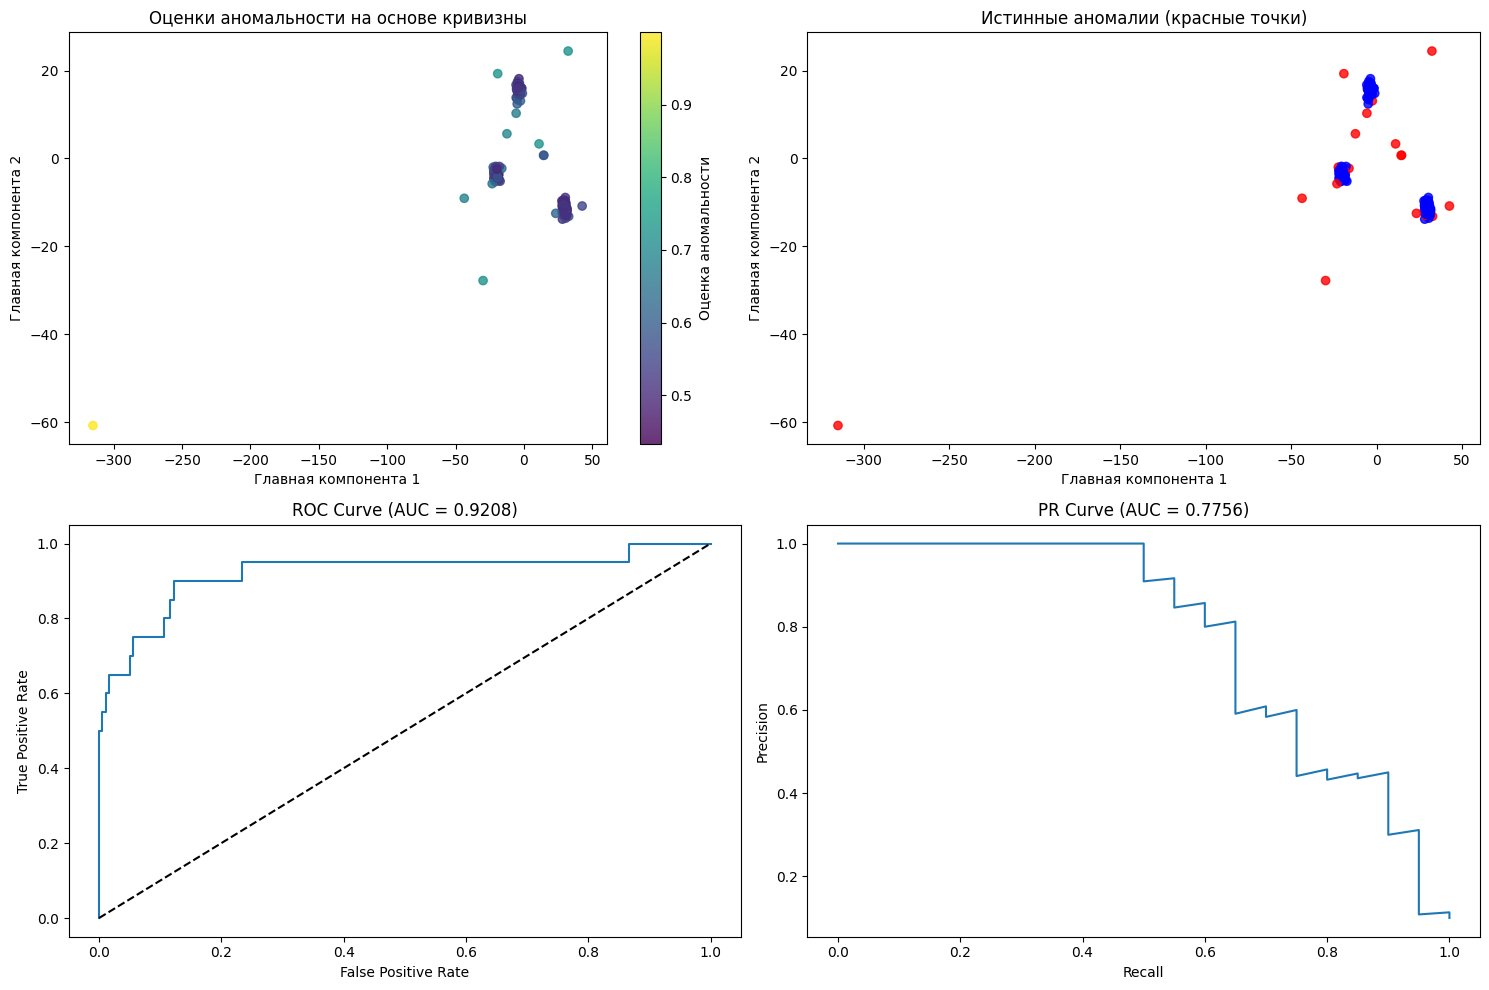

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, roc_curve
from sklearn.decomposition import PCA
from scipy.spatial.distance import pdist, squareform
from tqdm import tqdm

def generate_synthetic_data(n_samples=100, n_features=10, n_clusters=3, cluster_std=1.0, random_state=42):
    """
    Генерирует синтетические данные с заданным количеством кластеров.
    
    Args:
        n_samples: Количество образцов
        n_features: Количество признаков
        n_clusters: Количество кластеров
        cluster_std: Стандартное отклонение для кластеров
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Сгенерированные данные формы (n_samples, n_features)
    """
    np.random.seed(random_state)
    
    cluster_centers = np.random.randn(n_clusters, n_features) * 10
    
    X = np.zeros((n_samples, n_features))
    samples_per_cluster = n_samples // n_clusters
    
    for i in range(n_clusters):
        start_idx = i * samples_per_cluster
        end_idx = (i + 1) * samples_per_cluster if i < n_clusters - 1 else n_samples
        
        n_cluster_samples = end_idx - start_idx
        X[start_idx:end_idx] = cluster_centers[i] + np.random.randn(n_cluster_samples, n_features) * cluster_std
    
    np.random.shuffle(X)
    return X

def create_synthetic_anomalies(data, anomaly_ratio=0.2, anomaly_scale=5.0, random_state=42):
    """
    Создает синтетические аномалии путем добавления шума или изменения структуры данных.
    
    Args:
        data: Исходные данные
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Данные с аномалиями и индексы аномальных образцов
    """
    np.random.seed(random_state)
    data_with_anomalies = data.copy()
    n_samples = data.shape[0]
    n_features = data.shape[1]
    
    n_anomalies = int(n_samples * anomaly_ratio)
    anomaly_indices = np.random.choice(n_samples, n_anomalies, replace=False)
    
    for idx in anomaly_indices:
        anomaly_type = np.random.choice(['noise', 'shift', 'scale', 'structured'])
        
        if anomaly_type == 'noise':
            data_with_anomalies[idx] += np.random.randn(n_features) * anomaly_scale
            
        elif anomaly_type == 'shift':
            data_with_anomalies[idx] += anomaly_scale * np.random.randn()
            
        elif anomaly_type == 'scale':
            scale_factor = np.random.choice([anomaly_scale, 1/anomaly_scale])
            data_with_anomalies[idx] *= scale_factor
            
        else:  # 'structured'
            t = np.linspace(0, 10, n_features)
            freq = np.random.uniform(1, 5)
            amplitude = np.random.uniform(1, anomaly_scale)
            data_with_anomalies[idx] += amplitude * np.sin(2 * np.pi * freq * t)
    
    return data_with_anomalies, anomaly_indices

def estimate_curvature(data, n_neighbors=15):
    """
    Оценивает кривизну многообразия данных используя локальную аппроксимацию.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для локальной аппроксимации
        
    Returns:
        Массив оценок кривизны для каждой точки
    """
    n_samples, n_features = data.shape
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    indices = indices[:, 1:]
    distances = distances[:, 1:]
    
    # Оценка кривизны через PCA и отношение собственных значений
    curvatures = np.zeros(n_samples)
    
    for i in range(n_samples):
        neighborhood = data[indices[i]]
        center = data[i]
        
        centered_neighbors = neighborhood - center
        U, S, Vt = np.linalg.svd(centered_neighbors, full_matrices=False)
        
        # Отношение минимального ненулевого собственного значения к максимальному
        # характеризует "сплющенность" многообразия
        eigenvalues = S
        
        if len(eigenvalues) > 1:
            min_nonzero_eig = np.min(eigenvalues[eigenvalues > 1e-10]) if any(eigenvalues > 1e-10) else 1e-10
            max_eig = np.max(eigenvalues)
            flatness = min_nonzero_eig / (max_eig + 1e-10)
            
            # Формула для оценки кривизны: C(x_i) = 1 - λ_min/λ_max
            # Чем ближе к 1, тем больше кривизна
            curvatures[i] = 1.0 - flatness
        else:
            curvatures[i] = 0.0
    
    return curvatures

def compute_reconstruction_error(data, n_neighbors=15, n_components=None):
    """
    Вычисляет ошибку реконструкции для оценки кривизны.
    
    Args:
        data: Данные формы (n_samples, n_features)
        n_neighbors: Количество соседей для локальной аппроксимации
        n_components: Количество главных компонент (если None, определяется автоматически)
        
    Returns:
        Массив ошибок реконструкции для каждой точки
    """
    n_samples, n_features = data.shape
    
    if n_components is None:
        # По умолчанию используем половину размерности данных, но не более числа соседей
        n_components = min(n_features // 2, n_neighbors - 1)
        n_components = max(n_components, 1) 
    
    nbrs = NearestNeighbors(n_neighbors=n_neighbors+1).fit(data)
    distances, indices = nbrs.kneighbors(data)
    
    indices = indices[:, 1:]
    
    reconstruction_errors = np.zeros(n_samples)
    
    for i in range(n_samples):
        neighborhood = data[indices[i]]
        center = data[i]
        centered_neighbors = neighborhood - center
        
        # PCA для аппроксимации касательного пространства
        pca = PCA(n_components=n_components)
        projection = pca.fit_transform(centered_neighbors)
        reconstruction = pca.inverse_transform(projection)
        
        # Ошибка реконструкции: E(x_i) = (1/k) Σ ||x_j - x̂_j||²
        reconstruction_error = np.mean(np.sum((centered_neighbors - reconstruction)**2, axis=1))
        reconstruction_errors[i] = reconstruction_error
    
    if np.max(reconstruction_errors) > np.min(reconstruction_errors):
        reconstruction_errors = (reconstruction_errors - np.min(reconstruction_errors)) / (np.max(reconstruction_errors) - np.min(reconstruction_errors))
    
    return reconstruction_errors

def detect_anomalies_with_curvature(data, curvature_weight=0.5, reconstruction_weight=0.5, n_neighbors=15):
    """
    Обнаруживает аномалии с использованием кривизны многообразия.
    
    Args:
        data: Исходные данные
        curvature_weight: Вес оценки кривизны через собственные значения
        reconstruction_weight: Вес оценки через ошибку реконструкции
        n_neighbors: Количество соседей для локальной аппроксимации
        
    Returns:
        Оценки аномальности для каждой точки
    """
    curvatures = estimate_curvature(data, n_neighbors)
    reconstruction_errors = compute_reconstruction_error(data, n_neighbors)
    combined_scores = curvature_weight * curvatures + reconstruction_weight * reconstruction_errors
    return combined_scores

def evaluate_curvature_anomaly_detection(n_samples=200, n_features=10, anomaly_ratio=0.1, 
                                         anomaly_scale=5.0, n_neighbors=15, random_state=42):
    """
    Оценивает эффективность обнаружения аномалий с использованием кривизны многообразия.
    
    Args:
        n_samples: Количество образцов
        n_features: Количество признаков
        anomaly_ratio: Доля аномальных образцов
        anomaly_scale: Масштаб аномалий
        n_neighbors: Количество соседей для локальной аппроксимации
        random_state: Случайное состояние для воспроизводимости
        
    Returns:
        Метрики ROC AUC и PR AUC, а также оценки аномальности и истинные метки
    """
    synthetic_data = generate_synthetic_data(n_samples=n_samples, n_features=n_features, 
                                            n_clusters=3, random_state=random_state)
    
    data_with_anomalies, anomaly_indices = create_synthetic_anomalies(
        synthetic_data, anomaly_ratio=anomaly_ratio, anomaly_scale=anomaly_scale, 
        random_state=random_state
    )
    
    # Метки: 1 для аномалий, 0 для нормальных
    true_labels = np.zeros(n_samples)
    true_labels[anomaly_indices] = 1
    
    anomaly_scores = detect_anomalies_with_curvature(data_with_anomalies, 
                                                    curvature_weight=0.5, 
                                                    reconstruction_weight=0.5,
                                                    n_neighbors=n_neighbors)
    
    roc_auc = roc_auc_score(true_labels, anomaly_scores)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    pr_auc = auc(recall, precision)
    
    print(f"\nРезультаты обнаружения аномалий с помощью кривизны:")
    print(f"ROC AUC: {roc_auc:.4f}")
    print(f"PR AUC: {pr_auc:.4f}")
    
    visualize_results(data_with_anomalies, anomaly_scores, true_labels, roc_auc, pr_auc)
    
    return roc_auc, pr_auc, anomaly_scores, true_labels

def visualize_results(data, anomaly_scores, true_labels, roc_auc, pr_auc):
    """
    Визуализирует результаты обнаружения аномалий.
    
    Args:
        data: Исходные данные
        anomaly_scores: Оценки аномальности
        true_labels: Истинные метки (1 для аномалий, 0 для нормальных)
        roc_auc: Значение ROC AUC
        pr_auc: Значение PR AUC
    """
    # Уменьшение размерности для визуализации
    pca = PCA(n_components=2)
    data_2d = pca.fit_transform(data)
    
    plt.figure(figsize=(15, 10))
    
    plt.subplot(2, 2, 1)
    scatter = plt.scatter(data_2d[:, 0], data_2d[:, 1], c=anomaly_scores, 
                         cmap='viridis', alpha=0.8)
    plt.colorbar(scatter, label='Оценка аномальности')
    plt.xlabel('Главная компонента 1')
    plt.ylabel('Главная компонента 2')
    plt.title('Оценки аномальности на основе кривизны')
    
    plt.subplot(2, 2, 2)
    colors = ['blue' if label == 0 else 'red' for label in true_labels]
    plt.scatter(data_2d[:, 0], data_2d[:, 1], c=colors, alpha=0.8)
    plt.xlabel('Главная компонента 1')
    plt.ylabel('Главная компонента 2')
    plt.title('Истинные аномалии (красные точки)')
    
    # ROC кривая
    plt.subplot(2, 2, 3)
    fpr, tpr, _ = roc_curve(true_labels, anomaly_scores)
    plt.plot(fpr, tpr)
    plt.plot([0, 1], [0, 1], 'k--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title(f'ROC Curve (AUC = {roc_auc:.4f})')
    
    # PR кривая
    plt.subplot(2, 2, 4)
    precision, recall, _ = precision_recall_curve(true_labels, anomaly_scores)
    plt.plot(recall, precision)
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title(f'PR Curve (AUC = {pr_auc:.4f})')
    
    plt.tight_layout()
    plt.savefig('curvature_anomaly_detection.png')
    plt.show()

if __name__ == "__main__":

    params = {
        'n_samples': 200,         # Количество образцов
        'n_features': 10,         # Размерность данных
        'anomaly_ratio': 0.1,     # Доля аномалий
        'anomaly_scale': 10.0,     # Масштаб аномалий
        'n_neighbors': 15,        # Количество соседей для анализа локальной геометрии
        'random_state': 42        # Случайное состояние для воспроизводимости
    }
    
    roc_auc, pr_auc, scores, true_labels = evaluate_curvature_anomaly_detection(**params)
